In [1]:
import cv2
import ultralytics

print("OpenCV version:", cv2.__version__)
print("Ultralytics version:", ultralytics.__version__)
print("AI environment is ready!")

OpenCV version: 5.0.0
Ultralytics version: 8.4.155
AI environment is ready!


In [2]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [3]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera could not be opened")
else:
    print("Camera opened successfully")

cap.release()

Camera opened successfully


In [4]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

model = YOLO("yolo11n.pt")

results = model("car.jpg")

results[0].show()

FileNotFoundError: car.jpg does not exist

In [5]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\SAPNA KUMARI
['-1.14-windows.xml', '.anaconda', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.obs64', 'AI_Cloud_Vehicle_Detection.ipynb', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Figure_1.png', 'Figure_3.png', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{3b525ed9-5e20-11f0-af20-dbcfd44dfbdb}.TM.blf', 'NTUSER.DAT{3b525ed9-5e20-11f0-af20-dbcfd44dfbdb}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{3b525ed9-5e20-11f0-af20-dbcfd44dfbdb}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'sapna.py', 'Saved Games', 'scikit_learn_data', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Videos', 'yolo11n.pt']


In [6]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model("Figure_1.png")

results[0].show()


image 1/1 C:\Users\SAPNA KUMARI\Figure_1.png: 480x640 1 stop sign, 322.4ms
Speed: 21.4ms preprocess, 322.4ms inference, 23.2ms postprocess per image at shape (1, 3, 480, 640)


In [7]:
import requests

url = "https://ultralytics.com/images/bus.jpg"

response = requests.get(url)

with open("bus.jpg", "wb") as f:
    f.write(response.content)

print("Image downloaded successfully!")

Image downloaded successfully!


In [8]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model("bus.jpg")

results[0].show()


image 1/1 C:\Users\SAPNA KUMARI\bus.jpg: 640x480 4 persons, 1 bus, 229.2ms
Speed: 11.1ms preprocess, 229.2ms inference, 5.5ms postprocess per image at shape (1, 3, 640, 480)


In [9]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model("bus.jpg")

vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}

vehicle_count = {
    "car": 0,
    "motorcycle": 0,
    "bus": 0,
    "truck": 0
}

for box in results[0].boxes:
    class_id = int(box.cls[0])

    if class_id in vehicle_classes:
        vehicle_name = vehicle_classes[class_id]
        vehicle_count[vehicle_name] += 1

print("Vehicle Detection Results")
print("-------------------------")

for vehicle, count in vehicle_count.items():
    print(f"{vehicle}: {count}")

total = sum(vehicle_count.values())

print("-------------------------")
print("Total vehicles:", total)


image 1/1 C:\Users\SAPNA KUMARI\bus.jpg: 640x480 4 persons, 1 bus, 148.4ms
Speed: 5.7ms preprocess, 148.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)
Vehicle Detection Results
-------------------------
car: 0
motorcycle: 0
bus: 1
truck: 0
-------------------------
Total vehicles: 1


In [10]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera not available")
else:
    print("Camera connected successfully")

cap.release()

Camera connected successfully



image 1/1 C:\Users\SAPNA KUMARI\camera_frame.jpg: 480x640 1 microwave, 1 oven, 138.7ms
Speed: 3.0ms preprocess, 138.7ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Vehicle detection completed.


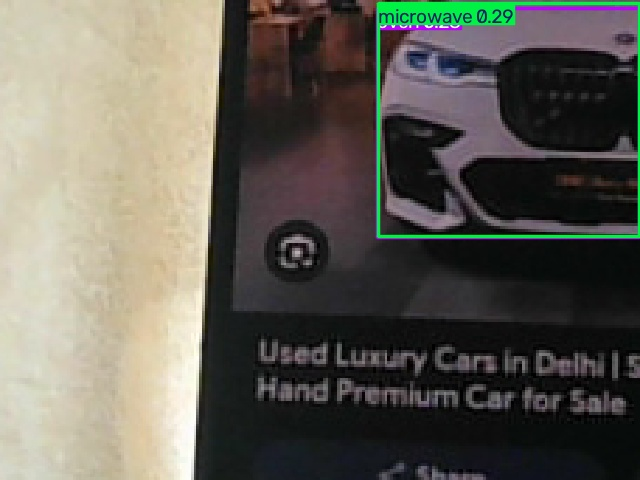

In [14]:
import cv2
from IPython.display import display, Image
import time

cap = cv2.VideoCapture(0)

# Give the camera a moment to start
time.sleep(2)

ret, frame = cap.read()

cap.release()

if not ret:
    print("Could not capture image from camera.")
else:
    # Save the captured frame
    cv2.imwrite("camera_frame.jpg", frame)

    # Run YOLO
    results = model("camera_frame.jpg")

    # Save annotated result
    results[0].save(filename="detected_frame.jpg")

    print("Vehicle detection completed.")

    display(Image(filename="detected_frame.jpg"))

In [15]:
!pip install fastapi uvicorn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------- ------------------- 1.0/2.0 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 4.6 MB/s  0:00:00

   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---------------------------------------- 0/9 [uvicorn]
   ---- ----------------------------------- 1/9 [typing-inspection]
   -------- ------------------------------- 2/9 [pydantic-core]
   -------- ------------------------------- 2/9 [

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [16]:
from fastapi import FastAPI
from datetime import datetime

app = FastAPI(
    title="AI Vehicle Detection Cloud API",
    description="API for real-time vehicle detection and traffic monitoring"
)

vehicle_data = {
    "cars": 0,
    "motorcycles": 0,
    "buses": 0,
    "trucks": 0,
    "total": 0,
    "timestamp": None
}

@app.get("/")
def home():
    return {
        "message": "AI Vehicle Detection Cloud API is running"
    }

@app.get("/api/vehicles")
def get_vehicle_data():
    return vehicle_data

print("FastAPI application created successfully!")

FastAPI application created successfully!


In [17]:
import threading
import uvicorn

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server started at http://127.0.0.1:8000")

FastAPI server started at http://127.0.0.1:8000


INFO:     Started server process [23712]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


In [20]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import requests
from datetime import datetime

vehicle_data = {
    "cars": 3,
    "motorcycles": 2,
    "buses": 1,
    "trucks": 1,
    "total": 7,
    "timestamp": datetime.now().isoformat()
}

print("Vehicle data prepared:")
print(vehicle_data)

Vehicle data prepared:
{'cars': 3, 'motorcycles': 2, 'buses': 1, 'trucks': 1, 'total': 7, 'timestamp': '2026-10-01T12:15:31.239900'}


In [22]:
from pydantic import BaseModel

class VehicleData(BaseModel):
    cars: int
    motorcycles: int
    buses: int
    trucks: int
    total: int
    timestamp: str


@app.post("/api/vehicles")
def update_vehicle_data(data: VehicleData):
    vehicle_data.update(data.model_dump())

    return {
        "message": "Vehicle data updated successfully",
        "data": vehicle_data
    }

print("POST /api/vehicles endpoint added successfully!")

POST /api/vehicles endpoint added successfully!


In [23]:
import requests
from datetime import datetime

payload = {
    "cars": 3,
    "motorcycles": 2,
    "buses": 1,
    "trucks": 1,
    "total": 7,
    "timestamp": datetime.now().isoformat()
}

response = requests.post(
    "http://127.0.0.1:8000/api/vehicles",
    json=payload
)

print("Status code:", response.status_code)
print("API response:")
print(response.json())

INFO:     127.0.0.1:50132 - "POST /api/vehicles HTTP/1.1" 200 OK
Status code: 200
API response:
{'message': 'Vehicle data updated successfully', 'data': {'cars': 3, 'motorcycles': 2, 'buses': 1, 'trucks': 1, 'total': 7, 'timestamp': '2026-10-01T12:16:33.951895'}}
INFO:     127.0.0.1:62951 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:63594 - "GET /api/vehicles HTTP/1.1" 200 OK


In [24]:
# Run YOLO vehicle detection
results = model("bus.jpg")

vehicle_classes = {
    2: "cars",
    3: "motorcycles",
    5: "buses",
    7: "trucks"
}

vehicle_count = {
    "cars": 0,
    "motorcycles": 0,
    "buses": 0,
    "trucks": 0
}

# Count detected vehicles
for box in results[0].boxes:
    class_id = int(box.cls[0])

    if class_id in vehicle_classes:
        vehicle_name = vehicle_classes[class_id]
        vehicle_count[vehicle_name] += 1

vehicle_count["total"] = sum(vehicle_count.values())

print("Real YOLO Vehicle Count")
print("-----------------------")
print(vehicle_count)


image 1/1 C:\Users\SAPNA KUMARI\bus.jpg: 640x480 4 persons, 1 bus, 144.3ms
Speed: 4.0ms preprocess, 144.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)
Real YOLO Vehicle Count
-----------------------
{'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1}


In [25]:
import requests
from datetime import datetime

payload = {
    "cars": vehicle_count["cars"],
    "motorcycles": vehicle_count["motorcycles"],
    "buses": vehicle_count["buses"],
    "trucks": vehicle_count["trucks"],
    "total": vehicle_count["total"],
    "timestamp": datetime.now().isoformat()
}

response = requests.post(
    "http://127.0.0.1:8000/api/vehicles",
    json=payload
)

print("Status code:", response.status_code)
print("Real YOLO data sent to FastAPI:")
print(response.json())

INFO:     127.0.0.1:59414 - "POST /api/vehicles HTTP/1.1" 200 OK
Status code: 200
Real YOLO data sent to FastAPI:
{'message': 'Vehicle data updated successfully', 'data': {'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:18:29.428389'}}
INFO:     127.0.0.1:54849 - "GET /api/vehicles HTTP/1.1" 200 OK


In [26]:
import sqlite3

# Create database
conn = sqlite3.connect("traffic_data.db")

cursor = conn.cursor()

# Create vehicle_data table
cursor.execute("""
CREATE TABLE IF NOT EXISTS vehicle_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    cars INTEGER,
    motorcycles INTEGER,
    buses INTEGER,
    trucks INTEGER,
    total INTEGER,
    timestamp TEXT
)
""")

conn.commit()
conn.close()

print("Database created successfully!")
print("Table: vehicle_data")

Database created successfully!
Table: vehicle_data


In [27]:
import sqlite3

# Connect to database
conn = sqlite3.connect("traffic_data.db")
cursor = conn.cursor()

# Save the latest YOLO vehicle data
cursor.execute("""
INSERT INTO vehicle_data
(cars, motorcycles, buses, trucks, total, timestamp)
VALUES (?, ?, ?, ?, ?, ?)
""", (
    vehicle_count["cars"],
    vehicle_count["motorcycles"],
    vehicle_count["buses"],
    vehicle_count["trucks"],
    vehicle_count["total"],
    payload["timestamp"]
))

conn.commit()
conn.close()

print("YOLO vehicle data saved to database successfully!")

YOLO vehicle data saved to database successfully!


In [28]:
import sqlite3

conn = sqlite3.connect("traffic_data.db")
cursor = conn.cursor()

cursor.execute("""
SELECT * FROM vehicle_data
ORDER BY id DESC
LIMIT 5
""")

records = cursor.fetchall()

conn.close()

print("Stored Vehicle Records")
print("----------------------")

for record in records:
    print(record)

Stored Vehicle Records
----------------------
(1, 0, 0, 1, 0, 1, '2026-10-01T12:18:29.428389')


In [29]:
import sqlite3

@app.post("/api/vehicles/save")
def save_vehicle_data(data: VehicleData):

    conn = sqlite3.connect("traffic_data.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO vehicle_data
    (cars, motorcycles, buses, trucks, total, timestamp)
    VALUES (?, ?, ?, ?, ?, ?)
    """, (
        data.cars,
        data.motorcycles,
        data.buses,
        data.trucks,
        data.total,
        data.timestamp
    ))

    conn.commit()

    record_id = cursor.lastrowid

    conn.close()

    return {
        "message": "Vehicle data saved to database",
        "record_id": record_id,
        "data": data.model_dump()
    }

print("Database API endpoint added successfully!")

Database API endpoint added successfully!


In [30]:
import requests
from datetime import datetime

payload = {
    "cars": vehicle_count["cars"],
    "motorcycles": vehicle_count["motorcycles"],
    "buses": vehicle_count["buses"],
    "trucks": vehicle_count["trucks"],
    "total": vehicle_count["total"],
    "timestamp": datetime.now().isoformat()
}

response = requests.post(
    "http://127.0.0.1:8000/api/vehicles/save",
    json=payload
)

print("Status code:", response.status_code)
print("API response:")
print(response.json())

INFO:     127.0.0.1:60958 - "POST /api/vehicles/save HTTP/1.1" 200 OK
Status code: 200
API response:
{'message': 'Vehicle data saved to database', 'record_id': 2, 'data': {'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:22:40.045987'}}


In [31]:
@app.get("/api/vehicles/history")
def get_vehicle_history():

    conn = sqlite3.connect("traffic_data.db")
    cursor = conn.cursor()

    cursor.execute("""
    SELECT id, cars, motorcycles, buses, trucks, total, timestamp
    FROM vehicle_data
    ORDER BY id DESC
    LIMIT 50
    """)

    records = cursor.fetchall()
    conn.close()

    history = []

    for record in records:
        history.append({
            "id": record[0],
            "cars": record[1],
            "motorcycles": record[2],
            "buses": record[3],
            "trucks": record[4],
            "total": record[5],
            "timestamp": record[6]
        })

    return {
        "count": len(history),
        "records": history
    }

print("Vehicle history API added successfully!")

Vehicle history API added successfully!
INFO:     127.0.0.1:51848 - "GET /api/vehicles/history HTTP/1.1" 200 OK


In [32]:
{
  "count": 2,
  "records": [
    {
      "id": 2,
      "cars": 0,
      "motorcycles": 0,
      "buses": 1,
      "trucks": 0,
      "total": 1,
      "timestamp": "2026-10-01T12:22:40..."
    },
    {
      "id": 1,
      "cars": 0,
      "motorcycles": 0,
      "buses": 1,
      "trucks": 0,
      "total": 1,
      "timestamp": "2026-10-01T12:18:29..."
    }
  ]
}

{'count': 2,
 'records': [{'id': 2,
   'cars': 0,
   'motorcycles': 0,
   'buses': 1,
   'trucks': 0,
   'total': 1,
   'timestamp': '2026-10-01T12:22:40...'},
  {'id': 1,
   'cars': 0,
   'motorcycles': 0,
   'buses': 1,
   'trucks': 0,
   'total': 1,
   'timestamp': '2026-10-01T12:18:29...'}]}

In [ ]:
!pip install streamlit

In [ ]:
dashboard_code = """
import streamlit as st
import requests
import pandas as pd

st.set_page_config(
    page_title="AI Traffic Monitoring Dashboard",
    page_icon="🚦",
    layout="wide"
)

st.title("🚦 AI-Powered Real-Time Traffic Monitoring")
st.write("Cloud-Based Vehicle Detection and Traffic Monitoring System")

API_URL = "http://127.0.0.1:8000"

try:
    # Get latest vehicle data
    response = requests.get(f"{API_URL}/api/vehicles")

    if response.status_code == 200:
        data = response.json()

        st.subheader("Current Vehicle Detection")

        col1, col2, col3, col4, col5 = st.columns(5)

        col1.metric("🚗 Cars", data["cars"])
        col2.metric("🏍️ Motorcycles", data["motorcycles"])
        col3.metric("🚌 Buses", data["buses"])
        col4.metric("🚚 Trucks", data["trucks"])
        col5.metric("🚘 Total", data["total"])

        st.write("Last Updated:", data["timestamp"])

    else:
        st.error("Could not get vehicle data from API.")

    # Get detection history
    history_response = requests.get(
        f"{API_URL}/api/vehicles/history"
    )

    if history_response.status_code == 200:

        history_data = history_response.json()

        st.subheader("Detection History")

        records = history_data["records"]

        if records:
            df = pd.DataFrame(records)
            st.dataframe(df, use_container_width=True)

        else:
            st.info("No detection history available.")

except Exception as e:
    st.error(f"API connection error: {e}")
"""

with open("dashboard.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("dashboard.py created successfully!")

In [1]:
print("New Jupyter kernel is working!")

New Jupyter kernel is working!


In [2]:
from fastapi import FastAPI
from pydantic import BaseModel
from datetime import datetime
import sqlite3
import threading
import uvicorn

# -----------------------------
# Create FastAPI application
# -----------------------------
app = FastAPI(
    title="AI Vehicle Detection Cloud API",
    description="API for real-time vehicle detection and traffic monitoring"
)

# -----------------------------
# Current vehicle data
# -----------------------------
vehicle_data = {
    "cars": 0,
    "motorcycles": 0,
    "buses": 0,
    "trucks": 0,
    "total": 0,
    "timestamp": None
}

# -----------------------------
# Database setup
# -----------------------------
conn = sqlite3.connect("traffic_data.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS vehicle_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    cars INTEGER,
    motorcycles INTEGER,
    buses INTEGER,
    trucks INTEGER,
    total INTEGER,
    timestamp TEXT
)
""")

conn.commit()
conn.close()

# -----------------------------
# Data model
# -----------------------------
class VehicleData(BaseModel):
    cars: int
    motorcycles: int
    buses: int
    trucks: int
    total: int
    timestamp: str

# -----------------------------
# Home API
# -----------------------------
@app.get("/")
def home():
    return {
        "message": "AI Vehicle Detection Cloud API is running"
    }

# -----------------------------
# Get latest vehicle data
# -----------------------------
@app.get("/api/vehicles")
def get_vehicle_data():
    return vehicle_data

# -----------------------------
# Update vehicle data
# -----------------------------
@app.post("/api/vehicles")
def update_vehicle_data(data: VehicleData):

    vehicle_data.update(data.model_dump())

    return {
        "message": "Vehicle data updated successfully",
        "data": vehicle_data
    }

# -----------------------------
# Save vehicle data to database
# -----------------------------
@app.post("/api/vehicles/save")
def save_vehicle_data(data: VehicleData):

    conn = sqlite3.connect("traffic_data.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO vehicle_data
    (cars, motorcycles, buses, trucks, total, timestamp)
    VALUES (?, ?, ?, ?, ?, ?)
    """, (
        data.cars,
        data.motorcycles,
        data.buses,
        data.trucks,
        data.total,
        data.timestamp
    ))

    conn.commit()

    record_id = cursor.lastrowid

    conn.close()

    return {
        "message": "Vehicle data saved to database",
        "record_id": record_id,
        "data": data.model_dump()
    }

# -----------------------------
# Vehicle history
# -----------------------------
@app.get("/api/vehicles/history")
def get_vehicle_history():

    conn = sqlite3.connect("traffic_data.db")
    cursor = conn.cursor()

    cursor.execute("""
    SELECT id, cars, motorcycles, buses, trucks, total, timestamp
    FROM vehicle_data
    ORDER BY id DESC
    LIMIT 50
    """)

    records = cursor.fetchall()

    conn.close()

    history = []

    for record in records:
        history.append({
            "id": record[0],
            "cars": record[1],
            "motorcycles": record[2],
            "buses": record[3],
            "trucks": record[4],
            "total": record[5],
            "timestamp": record[6]
        })

    return {
        "count": len(history),
        "records": history
    }

print("FastAPI backend recreated successfully!")
print("Database connected successfully!")
print("All API endpoints are ready!")

FastAPI backend recreated successfully!
Database connected successfully!
All API endpoints are ready!


In [3]:
import threading
import uvicorn

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server started successfully!")
print("API: http://127.0.0.1:8000")

FastAPI server started successfully!
API: http://127.0.0.1:8000


INFO:     Started server process [10868]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:58857 - "GET /api/vehicles?utm_source=chatgpt.com HTTP/1.1" 200 OK
INFO:     127.0.0.1:63576 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:63577 - "GET /api/vehicles/history HTTP/1.1" 200 OK


In [4]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [5]:
results = model("bus.jpg")

vehicle_classes = {
    2: "cars",
    3: "motorcycles",
    5: "buses",
    7: "trucks"
}

vehicle_count = {
    "cars": 0,
    "motorcycles": 0,
    "buses": 0,
    "trucks": 0
}

for box in results[0].boxes:
    class_id = int(box.cls[0])

    if class_id in vehicle_classes:
        vehicle_name = vehicle_classes[class_id]
        vehicle_count[vehicle_name] += 1

vehicle_count["total"] = sum(vehicle_count.values())

print("Real YOLO Vehicle Count")
print("-----------------------")
print(vehicle_count)


image 1/1 C:\Users\SAPNA KUMARI\bus.jpg: 640x480 4 persons, 1 bus, 170.5ms
Speed: 5.2ms preprocess, 170.5ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 480)
Real YOLO Vehicle Count
-----------------------
{'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1}


In [6]:
import requests
from datetime import datetime

payload = {
    "cars": vehicle_count["cars"],
    "motorcycles": vehicle_count["motorcycles"],
    "buses": vehicle_count["buses"],
    "trucks": vehicle_count["trucks"],
    "total": vehicle_count["total"],
    "timestamp": datetime.now().isoformat()
}

# Send current data to FastAPI
response = requests.post(
    "http://127.0.0.1:8000/api/vehicles",
    json=payload
)

print("FastAPI Status:", response.status_code)
print("Current vehicle data updated:")
print(response.json())

# Save the same data to SQLite database
save_response = requests.post(
    "http://127.0.0.1:8000/api/vehicles/save",
    json=payload
)

print("\nDatabase Status:", save_response.status_code)
print("Database response:")
print(save_response.json())

INFO:     127.0.0.1:59604 - "POST /api/vehicles HTTP/1.1" 200 OK
FastAPI Status: 200
Current vehicle data updated:
{'message': 'Vehicle data updated successfully', 'data': {'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:40:54.403119'}}
INFO:     127.0.0.1:59605 - "POST /api/vehicles/save HTTP/1.1" 200 OK

Database Status: 200
Database response:
{'message': 'Vehicle data saved to database', 'record_id': 3, 'data': {'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:40:54.403119'}}
INFO:     127.0.0.1:63327 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:63328 - "GET /api/vehicles/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:64077 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:64078 - "GET /api/vehicles/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:59511 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:59512 - "GET /api/vehicles/history HTTP/1.1" 200 OK


In [7]:
dashboard_code = """
import streamlit as st
import requests
import pandas as pd

st.set_page_config(
    page_title="AI Traffic Monitoring",
    page_icon="🚦",
    layout="wide"
)

API_URL = "http://127.0.0.1:8000"

st.title("🚦 AI-Powered Real-Time Traffic Monitoring")
st.write("Cloud-Based Vehicle Detection and Traffic Monitoring System")

if st.button("🔄 Refresh Data"):
    st.rerun()

try:

    response = requests.get(
        f"{API_URL}/api/vehicles",
        timeout=5
    )

    if response.status_code == 200:

        data = response.json()

        st.success("🟢 FastAPI Connected")

        st.subheader("Current Vehicle Detection")

        col1, col2, col3, col4, col5 = st.columns(5)

        col1.metric("🚗 Cars", data["cars"])
        col2.metric("🏍️ Motorcycles", data["motorcycles"])
        col3.metric("🚌 Buses", data["buses"])
        col4.metric("🚚 Trucks", data["trucks"])
        col5.metric("🚘 Total", data["total"])

        st.write("Last Updated:", data["timestamp"])

        st.subheader("📊 Vehicle Distribution")

        chart_data = pd.DataFrame({
            "Vehicle Type": [
                "Cars",
                "Motorcycles",
                "Buses",
                "Trucks"
            ],
            "Count": [
                data["cars"],
                data["motorcycles"],
                data["buses"],
                data["trucks"]
            ]
        })

        st.bar_chart(
            chart_data.set_index("Vehicle Type")
        )

    history_response = requests.get(
        f"{API_URL}/api/vehicles/history",
        timeout=5
    )

    if history_response.status_code == 200:

        history_data = history_response.json()
        records = history_data["records"]

        st.subheader("📋 Detection History")

        if records:

            df = pd.DataFrame(records)

            st.dataframe(
                df,
                use_container_width=True
            )

            st.subheader("📈 Traffic Detection Trend")

            trend_df = df[
                ["id", "cars", "motorcycles",
                 "buses", "trucks", "total"]
            ].copy()

            trend_df = trend_df.sort_values("id")
            trend_df = trend_df.set_index("id")

            st.line_chart(trend_df)

        else:
            st.info("No detection history available.")

except requests.exceptions.ConnectionError:

    st.error(
        "🔴 Cannot connect to FastAPI. "
        "Make sure FastAPI is running on port 8000."
    )

except Exception as e:

    st.error(f"Dashboard error: {e}")

st.markdown("---")

st.write(
    "AI Model: YOLO11n | "
    "Backend: FastAPI | "
    "Database: SQLite | "
    "Dashboard: Streamlit"
)
"""

with open("dashboard.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("Advanced dashboard created successfully!")

Advanced dashboard created successfully!
INFO:     127.0.0.1:50781 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:50782 - "GET /api/vehicles/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:56221 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:50908 - "GET /api/vehicles/history HTTP/1.1" 200 OK


In [8]:
import cv2

cap = cv2.VideoCapture(0)

if cap.isOpened():
    print("Camera opened successfully!")
else:
    print("Camera could not be opened.")

cap.release()

Camera opened successfully!


In [9]:
import cv2
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolo11n.pt")

# Open webcam
cap = cv2.VideoCapture(0)

vehicle_classes = {
    2: "cars",
    3: "motorcycles",
    5: "buses",
    7: "trucks"
}

while True:

    ret, frame = cap.read()

    if not ret:
        print("Camera frame could not be read.")
        break

    # YOLO detection
    results = model(frame, verbose=False)

    # Vehicle counters
    vehicle_count = {
        "cars": 0,
        "motorcycles": 0,
        "buses": 0,
        "trucks": 0
    }

    # Count vehicles
    for box in results[0].boxes:

        class_id = int(box.cls[0])

        if class_id in vehicle_classes:

            vehicle_name = vehicle_classes[class_id]
            vehicle_count[vehicle_name] += 1

    # Total vehicles
    total = sum(vehicle_count.values())

    # Draw YOLO detections
    annotated_frame = results[0].plot()

    # Display vehicle counts
    cv2.putText(
        annotated_frame,
        f"Cars: {vehicle_count['cars']}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Motorcycles: {vehicle_count['motorcycles']}",
        (20, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Buses: {vehicle_count['buses']}",
        (20, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Trucks: {vehicle_count['trucks']}",
        (20, 130),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Total Vehicles: {total}",
        (20, 165),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    # Show camera
    cv2.imshow("AI Real-Time Vehicle Detection", annotated_frame)

    # Press Q to stop
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

INFO:     127.0.0.1:50441 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:50442 - "GET /api/vehicles/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:59642 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:59643 - "GET /api/vehicles/history HTTP/1.1" 200 OK


KeyboardInterrupt: 

In [1]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/api/vehicles/history"
)

print("Status:", response.status_code)

data = response.json()

print("Total records:", data["count"])

print("\nLatest records:")
for record in data["records"][:5]:
    print(record)

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /api/vehicles/history (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [2]:
import threading
import uvicorn

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server started!")
print("API: http://127.0.0.1:8000")

FastAPI server started!
API: http://127.0.0.1:8000


Exception in thread Thread-4 (run_server):
Traceback (most recent call last):
  File "C:\Program Files\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Program Files\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SAPNA KUMARI\AppData\Local\Temp\ipykernel_18024\2225171934.py", line 5, in run_server
    uvicorn.run(app, host="127.0.0.1", port=8000)
                ^^^
NameError: name 'app' is not defined


In [3]:
from fastapi import FastAPI
from pydantic import BaseModel
import sqlite3

app = FastAPI(
    title="AI Vehicle Detection Cloud API",
    description="API for real-time vehicle detection and traffic monitoring"
)

vehicle_data = {
    "cars": 0,
    "motorcycles": 0,
    "buses": 0,
    "trucks": 0,
    "total": 0,
    "timestamp": None
}

# Create database/table if it does not already exist
conn = sqlite3.connect("traffic_data.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS vehicle_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    cars INTEGER,
    motorcycles INTEGER,
    buses INTEGER,
    trucks INTEGER,
    total INTEGER,
    timestamp TEXT
)
""")

conn.commit()
conn.close()


class VehicleData(BaseModel):
    cars: int
    motorcycles: int
    buses: int
    trucks: int
    total: int
    timestamp: str


@app.get("/")
def home():
    return {
        "message": "AI Vehicle Detection Cloud API is running"
    }


@app.get("/api/vehicles")
def get_vehicle_data():
    return vehicle_data


@app.post("/api/vehicles")
def update_vehicle_data(data: VehicleData):
    vehicle_data.update(data.model_dump())

    return {
        "message": "Vehicle data updated successfully",
        "data": vehicle_data
    }


@app.post("/api/vehicles/save")
def save_vehicle_data(data: VehicleData):

    conn = sqlite3.connect("traffic_data.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO vehicle_data
    (cars, motorcycles, buses, trucks, total, timestamp)
    VALUES (?, ?, ?, ?, ?, ?)
    """, (
        data.cars,
        data.motorcycles,
        data.buses,
        data.trucks,
        data.total,
        data.timestamp
    ))

    conn.commit()

    record_id = cursor.lastrowid

    conn.close()

    return {
        "message": "Vehicle data saved to database",
        "record_id": record_id,
        "data": data.model_dump()
    }


@app.get("/api/vehicles/history")
def get_vehicle_history():

    conn = sqlite3.connect("traffic_data.db")
    cursor = conn.cursor()

    cursor.execute("""
    SELECT id, cars, motorcycles, buses, trucks, total, timestamp
    FROM vehicle_data
    ORDER BY id DESC
    LIMIT 50
    """)

    records = cursor.fetchall()
    conn.close()

    history = []

    for record in records:
        history.append({
            "id": record[0],
            "cars": record[1],
            "motorcycles": record[2],
            "buses": record[3],
            "trucks": record[4],
            "total": record[5],
            "timestamp": record[6]
        })

    return {
        "count": len(history),
        "records": history
    }


print("FastAPI app created successfully!")
print("Database connected successfully!")

FastAPI app created successfully!
Database connected successfully!


In [4]:
import threading
import uvicorn

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

server_thread = threading.Thread(
    target=run_server,
    daemon=True
)

server_thread.start()

print("FastAPI server started successfully!")
print("API: http://127.0.0.1:8000")

FastAPI server started successfully!
API: http://127.0.0.1:8000


INFO:     Started server process [18024]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


In [5]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/api/vehicles/history"
)

print("Status:", response.status_code)

data = response.json()

print("Total records:", data["count"])

print("\nLatest records:")

for record in data["records"][:10]:
    print(record)

INFO:     127.0.0.1:58218 - "GET /api/vehicles/history HTTP/1.1" 200 OK
Status: 200
Total records: 3

Latest records:
{'id': 3, 'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:40:54.403119'}
{'id': 2, 'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:22:40.045987'}
{'id': 1, 'cars': 0, 'motorcycles': 0, 'buses': 1, 'trucks': 0, 'total': 1, 'timestamp': '2026-10-01T12:18:29.428389'}


In [6]:
import cv2
import requests
import time
from datetime import datetime
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

cap = cv2.VideoCapture(0)

vehicle_classes = {
    2: "cars",
    3: "motorcycles",
    5: "buses",
    7: "trucks"
}

start_time = time.time()
last_send_time = 0

print("Live vehicle detection started.")
print("Running for 10 seconds...")

while time.time() - start_time < 10:

    ret, frame = cap.read()

    if not ret:
        print("Camera frame could not be read.")
        break

    results = model(frame, verbose=False)

    vehicle_count = {
        "cars": 0,
        "motorcycles": 0,
        "buses": 0,
        "trucks": 0
    }

    for box in results[0].boxes:

        class_id = int(box.cls[0])

        if class_id in vehicle_classes:

            vehicle_name = vehicle_classes[class_id]

            vehicle_count[vehicle_name] += 1

    total = sum(vehicle_count.values())

    # Send data every 2 seconds
    if time.time() - last_send_time >= 2:

        payload = {
            "cars": vehicle_count["cars"],
            "motorcycles": vehicle_count["motorcycles"],
            "buses": vehicle_count["buses"],
            "trucks": vehicle_count["trucks"],
            "total": total,
            "timestamp": datetime.now().isoformat()
        }

        try:

            response = requests.post(
                "http://127.0.0.1:8000/api/vehicles",
                json=payload,
                timeout=3
            )

            save_response = requests.post(
                "http://127.0.0.1:8000/api/vehicles/save",
                json=payload,
                timeout=3
            )

            print(
                "Data sent:",
                payload,
                "| DB status:",
                save_response.status_code
            )

        except Exception as e:

            print("API error:", e)

        last_send_time = time.time()

    annotated_frame = results[0].plot()

    cv2.putText(
        annotated_frame,
        f"Cars: {vehicle_count['cars']}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Motorcycles: {vehicle_count['motorcycles']}",
        (20, 75),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Buses: {vehicle_count['buses']}",
        (20, 110),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Trucks: {vehicle_count['trucks']}",
        (20, 145),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow(
        "AI Real-Time Vehicle Detection",
        annotated_frame
    )

    cv2.waitKey(1)

cap.release()
cv2.destroyAllWindows()

print("Live detection completed.")

Live vehicle detection started.
Running for 10 seconds...
INFO:     127.0.0.1:61961 - "POST /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:61962 - "POST /api/vehicles/save HTTP/1.1" 200 OK
Data sent: {'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:01:14.246097'} | DB status: 200
Live detection completed.


In [7]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/api/vehicles/history"
)

data = response.json()

print("Total records:", data["count"])

print("\nLatest record:")
print(data["records"][0])

INFO:     127.0.0.1:52534 - "GET /api/vehicles/history HTTP/1.1" 200 OK
Total records: 4

Latest record:
{'id': 4, 'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:01:14.246097'}


In [8]:
import cv2
import requests
import time
from datetime import datetime
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
cap = cv2.VideoCapture(0)

vehicle_classes = {
    2: "cars",
    3: "motorcycles",
    5: "buses",
    7: "trucks"
}

start_time = time.time()
last_send = 0

print("🚗 Live vehicle detection started...")
print("⏱️ Running for 10 seconds...")

while time.time() - start_time < 10:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame, verbose=False)

    counts = {
        "cars": 0,
        "motorcycles": 0,
        "buses": 0,
        "trucks": 0
    }

    for box in results[0].boxes:
        class_id = int(box.cls[0])

        if class_id in vehicle_classes:
            counts[vehicle_classes[class_id]] += 1

    total = sum(counts.values())

    # Send once every 2 seconds
    if time.time() - last_send >= 2:

        payload = {
            **counts,
            "total": total,
            "timestamp": datetime.now().isoformat()
        }

        response = requests.post(
            "http://127.0.0.1:8000/api/vehicles",
            json=payload
        )

        save = requests.post(
            "http://127.0.0.1:8000/api/vehicles/save",
            json=payload
        )

        print("Data sent:", payload)
        print("Database status:", save.status_code)

        last_send = time.time()

    cv2.imshow(
        "AI Vehicle Detection",
        results[0].plot()
    )

    cv2.waitKey(1)

cap.release()
cv2.destroyAllWindows()

print("✅ 10-second detection completed!")

🚗 Live vehicle detection started...
⏱️ Running for 10 seconds...
INFO:     127.0.0.1:53043 - "POST /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:53044 - "POST /api/vehicles/save HTTP/1.1" 200 OK
Data sent: {'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:29.331292'}
Database status: 200
INFO:     127.0.0.1:53046 - "POST /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:53047 - "POST /api/vehicles/save HTTP/1.1" 200 OK
Data sent: {'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:31.516613'}
Database status: 200
INFO:     127.0.0.1:53048 - "POST /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:53049 - "POST /api/vehicles/save HTTP/1.1" 200 OK
Data sent: {'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:33.768294'}
Database status: 200
INFO:     127.0.0.1:53050 - "POST /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:53051 - "POST /api/

In [9]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/api/vehicles/history"
)

data = response.json()

print("Total records:", data["count"])

print("\nLatest 5 records:")

for record in data["records"][:5]:
    print(record)

INFO:     127.0.0.1:63317 - "GET /api/vehicles/history HTTP/1.1" 200 OK
Total records: 8

Latest 5 records:
{'id': 8, 'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:36.045297'}
{'id': 7, 'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:33.768294'}
{'id': 6, 'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:31.516613'}
{'id': 5, 'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:04:29.331292'}
{'id': 4, 'cars': 0, 'motorcycles': 0, 'buses': 0, 'trucks': 0, 'total': 0, 'timestamp': '2026-10-01T13:01:14.246097'}
INFO:     127.0.0.1:58208 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:61602 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:61603 - "GET /api/vehicles/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:61604 - "GET /api/vehicles HTTP/1.1" 200 OK
INFO:     127.0.0.1:59442 - "GET 